# Multimodal Animal Verification Pipeline 

| Component | Model | Task |
|-----------|-------|------|
| NLP | `dslim/bert-base-NER` (fine-tuned) | Extract `ANIMAL` entities from free-form text |
| CV  | `ResNet-18` (fine-tuned) | Classify the animal present in an image |


## 0. Setup

In [1]:
import os
import sys
import glob
import warnings

import torch
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display, HTML

ROOT = os.path.abspath('..')
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

warnings.filterwarnings('ignore')

from src.classifier.inference import load_model as load_cv_model
from src.classifier.inference import predict as predict_cv
from src.ner.inference import load_ner_pipeline, extract_animal_names

print(f"Python: {sys.executable}")

Python: /Users/zaharguzij/Documents/GitHub/Intership_test/.venv/bin/python


In [ ]:
CV_MODEL_PATH  = "../models/best_animal_classifier.pth"
NER_MODEL_PATH = "../models/ner_animal/best_model"
DATA_DIR       = "../data/raw-img"

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")
print(f"Device: {DEVICE}")

cv_model, class_names = load_cv_model(CV_MODEL_PATH, device=DEVICE)

ner_pipeline = load_ner_pipeline(
    NER_MODEL_PATH,
    device=0 if DEVICE.type == "cuda" else -1,
)


Device: cpu
Loading CV model...
Loading NER model...


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 8263.12it/s]


Ready. Classes: ['butterfly', 'cat', 'chicken', 'cow', 'dog', 'elephant', 'horse', 'sheep', 'spider', 'squirrel']


In [ ]:
def get_first_image(animal: str) -> str:
    """Return the path to the first available image for a given animal class."""
    pattern = os.path.join(DATA_DIR, animal, "*")
    files = sorted(glob.glob(pattern))
    if not files:
        raise FileNotFoundError(f"No images found for '{animal}' in {DATA_DIR}/{animal}/")
    return files[0]

for cls in class_names:
    path = get_first_image(cls)
    print(f"  {cls:<12} -> {os.path.basename(path)}")

  butterfly    -> OIP--04ndbWy7I04gsPgu9qOeQHaHs.jpeg
  cat          -> 1.jpeg
  chicken      -> 10.jpeg
  cow          -> OIP---lAIbDlHKmejDpqrXq6vAAAAA.jpeg
  dog          -> OIF-e2bexWrojgtQnAPPcUfOWQ.jpeg
  elephant     -> OIP---LeldVL441fx5S66TGgVQAAAA.jpeg
  horse        -> OIP---MGqQIhmz3OEPYP-46_xwHaFj.jpeg
  sheep        -> OIP--5EOVD9HIiHEqNd8PZjFogHaII.jpeg
  spider       -> OIP--1GKxNzkhVbR_eyVRCdp9QHaE6.jpeg
  squirrel     -> OIP--0Yr2a_yg2hs5QgCoHAOnAHaLJ.jpeg


---
## Visualisation Helper

In [15]:
def evaluate_and_display(
    text: str,
    image_path: str,
    min_confidence: float = 0.0,
) -> bool:
    extracted = extract_animal_names(text, ner_pipeline, min_confidence)
    extracted_lower = [a.lower() for a in extracted]

    cv_results = predict_cv(image_path, cv_model, class_names, DEVICE, top_k=3)
    top_animal, top_conf = cv_results[0]

    is_match = top_animal.lower() in extracted_lower

    fig, axes = plt.subplots(1, 2, figsize=(10, 4),
                             gridspec_kw={"width_ratios": [1, 1.4]})

    ax_img = axes[0]
    try:
        img = Image.open(image_path).convert("RGB")
        ax_img.imshow(img)
    except (FileNotFoundError, OSError):
        ax_img.text(0.5, 0.5, "Image not found",
                    ha="center", va="center", fontsize=12, color="gray")
    ax_img.axis("off")
    ax_img.set_title("Input Image", fontsize=11, fontweight="bold", pad=8)

    ax_bar = axes[1]
    labels = [r[0].capitalize() for r in cv_results]
    values = [r[1] for r in cv_results]
    colors = [
        "#2ecc71" if is_match and i == 0 else
        "#e74c3c" if not is_match and i == 0 else
        "#95a5a6"
        for i in range(len(labels))
    ]
    bars = ax_bar.barh(labels[::-1], values[::-1], color=colors[::-1],
                       height=0.5, edgecolor="white")
    ax_bar.set_xlim(0, 100)
    ax_bar.set_xlabel("Confidence (%)", fontsize=10)
    ax_bar.set_title("CV Top-3 Predictions", fontsize=11, fontweight="bold", pad=8)
    ax_bar.spines[["top", "right"]].set_visible(False)
    for bar, val in zip(bars, values[::-1]):
        ax_bar.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
                    f"{val:.1f}%", va="center", fontsize=9)

    result_text = "MATCH — TRUE" if is_match else "MISMATCH — FALSE"
    result_color = "#27ae60" if is_match else "#c0392b"
    ner_text = ", ".join(extracted) if extracted else "none detected"

    fig.text(0.01, -0.05, f"Input   : {text}", fontsize=10, va="top")
    fig.text(0.01, -0.12, f"NER     : {ner_text}", fontsize=10, va="top")
    fig.text(0.01, -0.19, f"CV      : {top_animal.capitalize()} ({top_conf:.1f}%)", fontsize=10, va="top")
    fig.text(0.01, -0.26, f"Result  : {result_text}", fontsize=11,
             va="top", fontweight="bold", color=result_color)

    plt.tight_layout()
    plt.show()

    return is_match

---
## 1. Standard Use Cases

Baseline tests where the text is straightforward and either clearly matches or contradicts the image.

Test 1.1 - Perfect match
Expected: TRUE

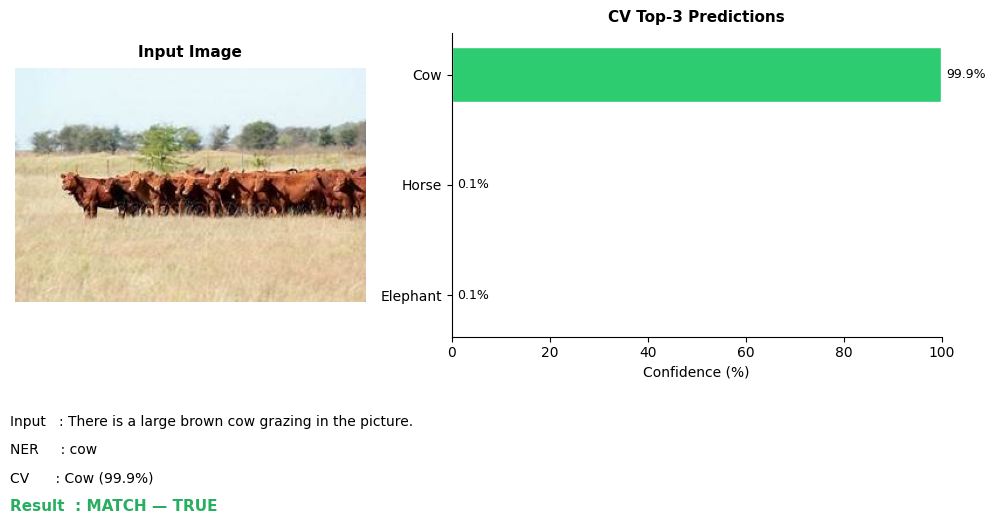

True

In [16]:
image_cow = get_first_image("cow")

evaluate_and_display(
    text="There is a large brown cow grazing in the picture.",
    image_path=image_cow,
)

Test 1.2 - Clear mismatch
Expected: FALSE - image contains a cow, text mentions a cat

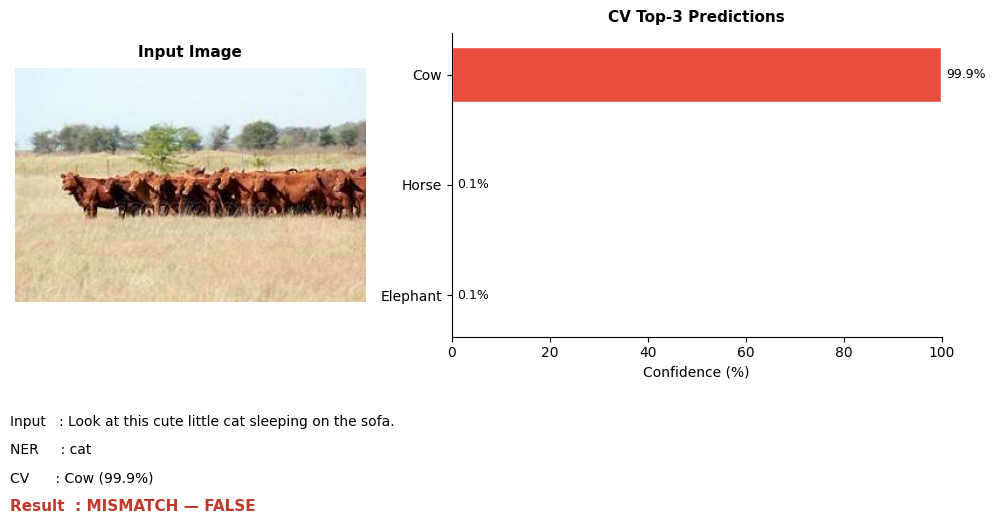

False

In [17]:
evaluate_and_display(
    text="Look at this cute little cat sleeping on the sofa.",
    image_path=image_cow,
)

---
## 2. Edge Cases

Tests that probe robustness: ambiguous phrasing, multiple entities, zero entities, and capitalisation variation.

Edge case 2.1 - Multiple animals in text
Image is a cow. Text mentions both horse and cow.
Expected: TRUE - match on 'cow'

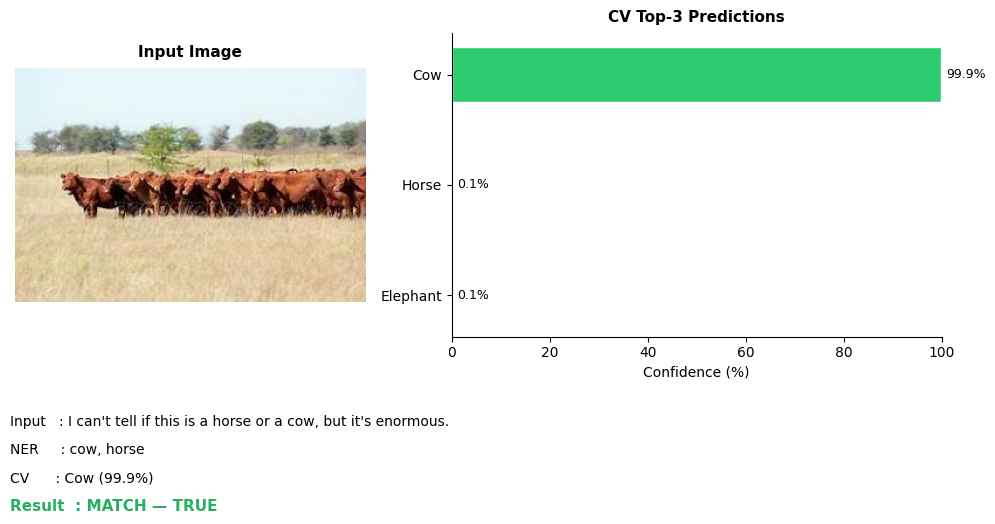

True

In [18]:
evaluate_and_display(
    text="I can't tell if this is a horse or a cow, but it's enormous.",
    image_path=image_cow,
)

Edge case 2.2 - Zero entities in text (false-positive prevention)
Image contains an animal, but text describes only the background.
Expected: FALSE - no animal entity extracted, no match possible

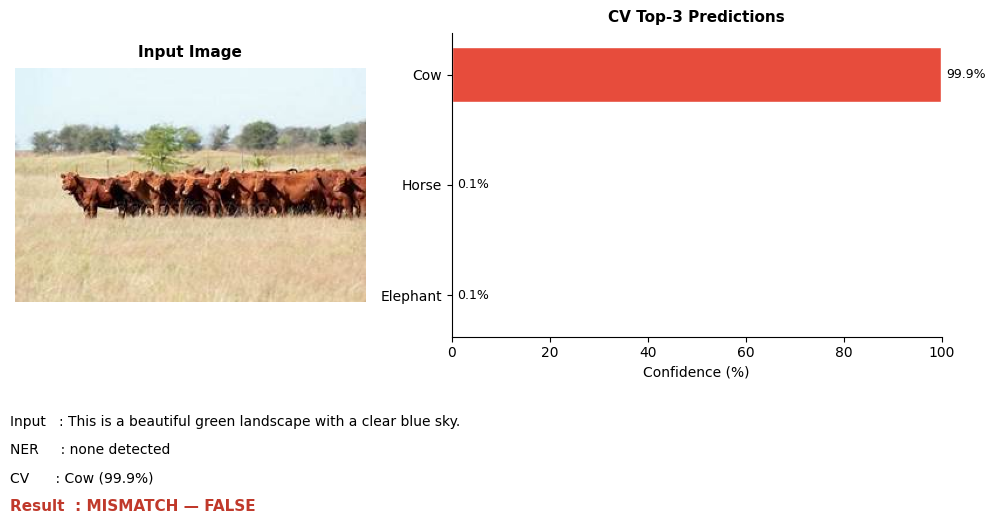

False

In [19]:
evaluate_and_display(
    text="This is a beautiful green landscape with a clear blue sky.",
    image_path=image_cow,
)

Edge case 2.3 - Capitalisation and punctuation variation
NER and CV comparison must be case-insensitive.
Expected: TRUE

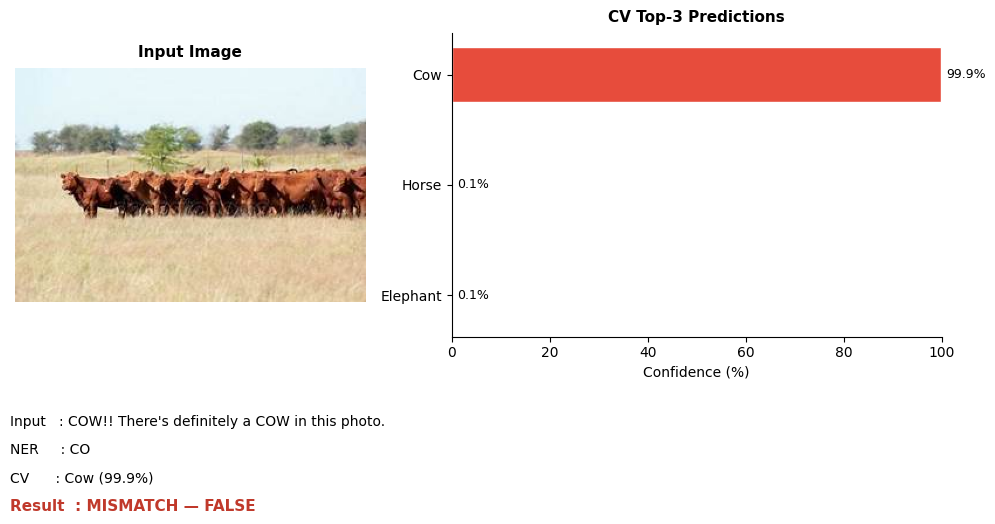

False

In [20]:
evaluate_and_display(
    text="COW!! There's definitely a COW in this photo.",
    image_path=image_cow,
)

Edge case 2.4 - Indirect / figurative reference
The text does not name the animal directly.
Expected: FALSE - NER cannot extract an implicit reference

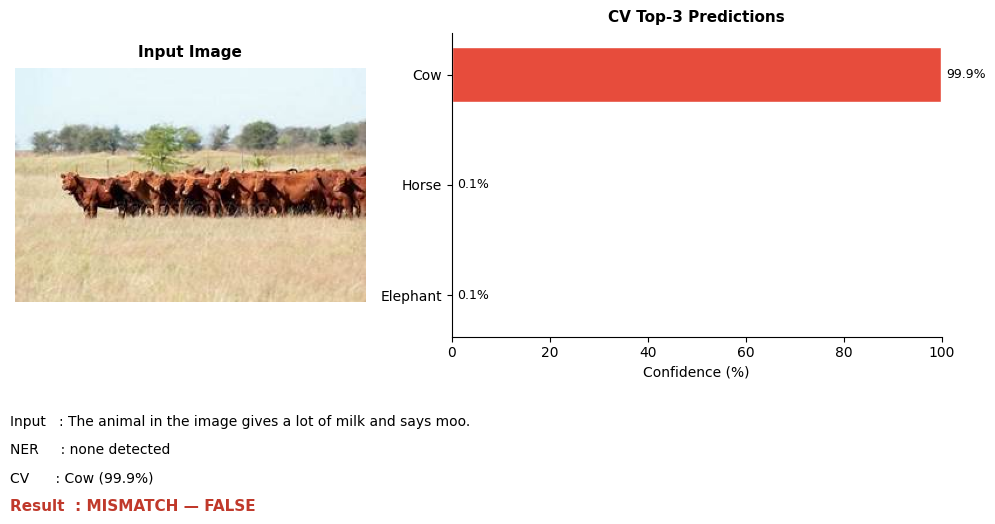

False

In [21]:
evaluate_and_display(
    text="The animal in the image gives a lot of milk and says moo.",
    image_path=image_cow,
)

Edge case 2.5 - NER confidence threshold
Raising min_confidence filters out low-certainty extractions.
Expected: True

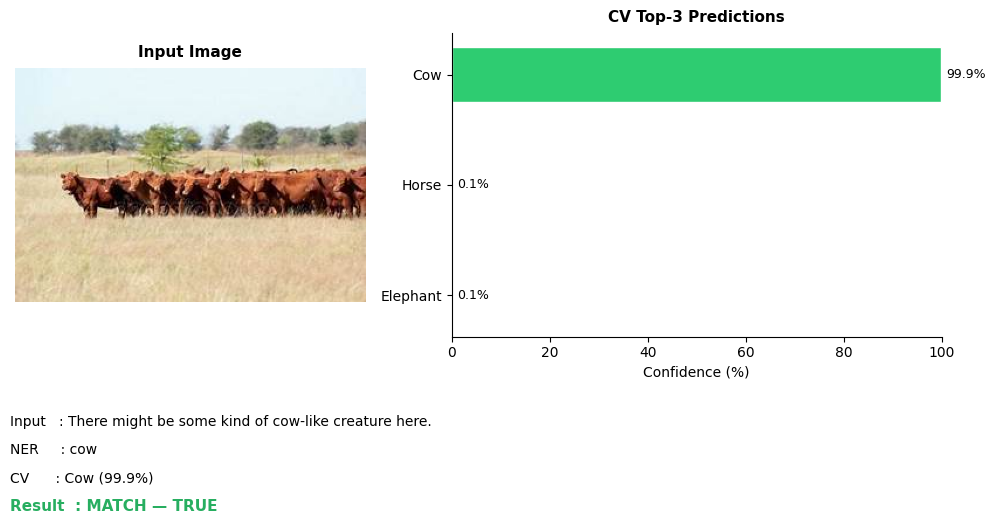

True

In [22]:
evaluate_and_display(
    text="There might be some kind of cow-like creature here.",
    image_path=image_cow,
    min_confidence=0.99,
)

---
## 3. Cross-class Verification

End-to-end tests across several supported animal classes to confirm the pipeline generalises beyond a single class.


Test: A dog is running in the park.


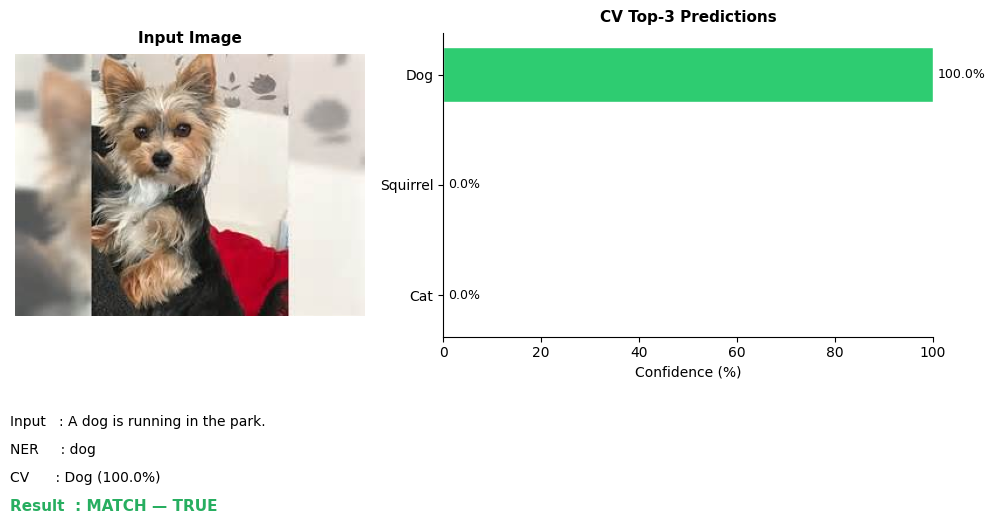


Test: There is a large elephant in the savanna.


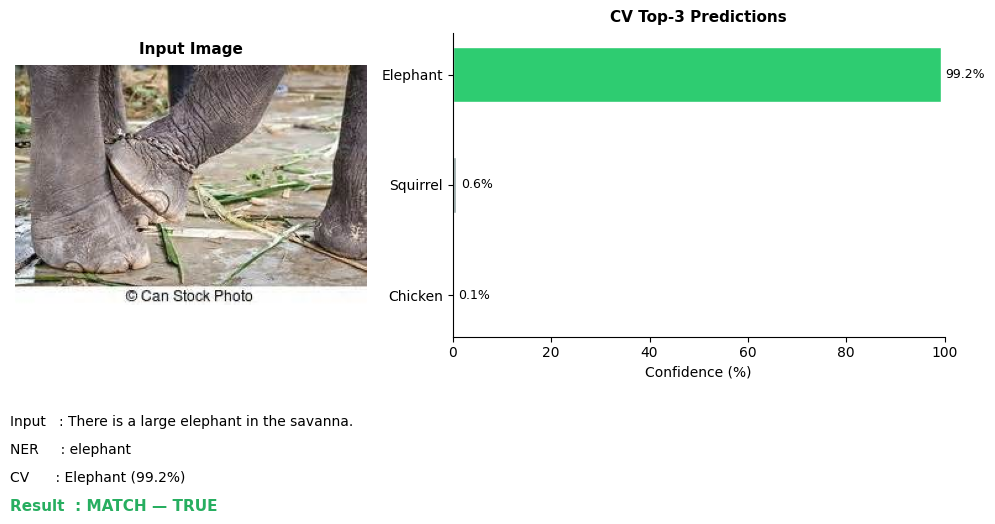


Test: A butterfly rests on a flower.


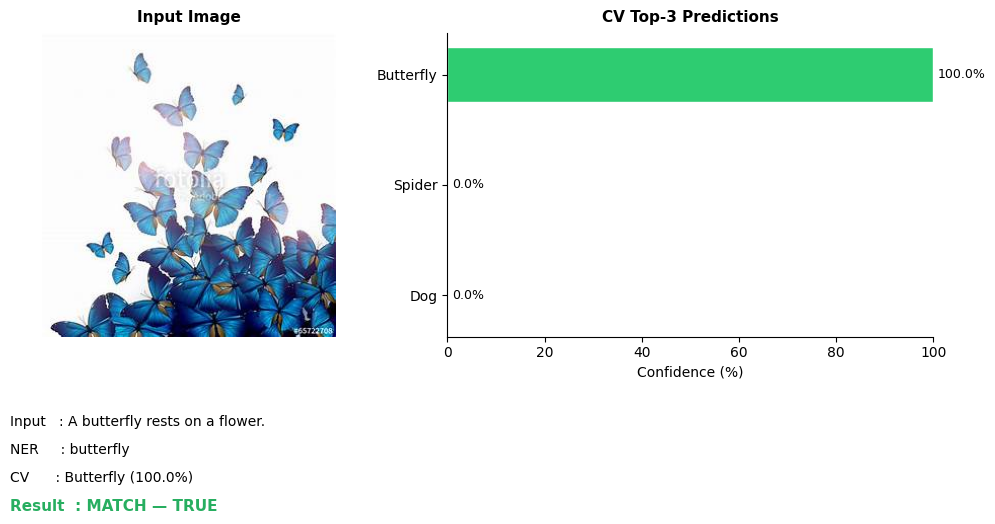


Test: A spider is weaving its web.


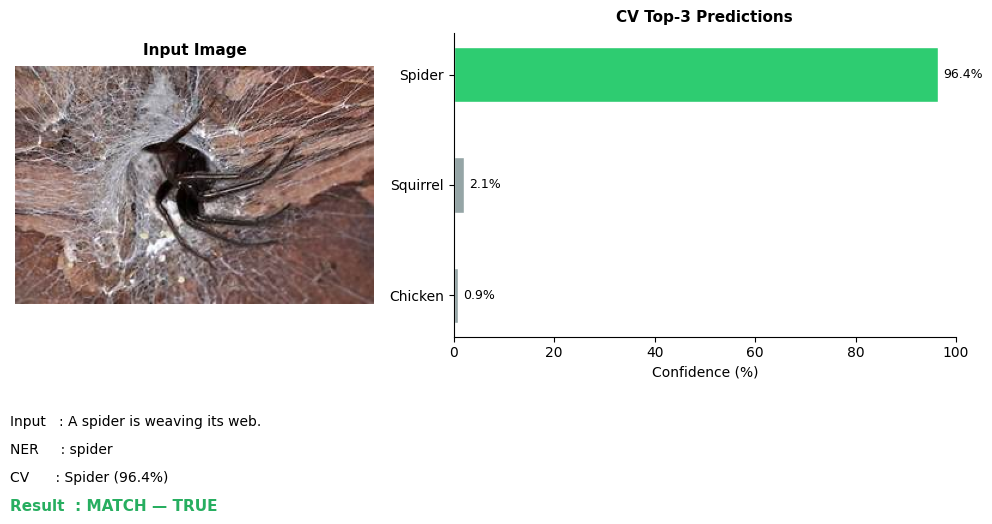

In [23]:
cross_class_tests = [
    ("A dog is running in the park.",             "dog"),
    ("There is a large elephant in the savanna.", "elephant"),
    ("A butterfly rests on a flower.",            "butterfly"),
    ("A spider is weaving its web.",              "spider"),
]

for text, animal in cross_class_tests:
    path = get_first_image(animal)
    print(f"\nTest: {text}")
    evaluate_and_display(text=text, image_path=path)